# Bank Marketing Analysis

**Project Goal:** Explore the bank marketing dataset to identify patterns in customer responses, evaluate hypotheses, and provide insights to improve marketing campaigns.

**Notebook Workflow:**
1. Setup (imports, database connections)
2. Load Data (import_data.py)
3. Data Exploration
4. Hypotheses
5. Data Cleaning / Transformation
6. Analysis (SQL or pandas)
7. Visualization
8. Insights / Interpretation
9. Next Steps

In [ ]:
# SETUP: Imports & Database Connection

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import sqlite3
from sqlalchemy import create_engine
import seaborn as sns
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root / "scripts"))

%load_ext sql
%config SqlMagic.style = '_DEPRECATED_DEFAULT'
%config SqlMagic.autopandas = True

%matplotlib inline
plt.style.use('seaborn-v0_8')

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


## Load Data
Load and check with quick preview.

In [12]:
from import_data import df
df.head()

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married        NaN      no     1506     yes   no   
4   33           NaN   single        NaN      no        1      no   no   

  contact  day_of_week month  duration  campaign  pdays  previous poutcome   y  
0     NaN            5   may       261         1     -1         0      NaN  no  
1     NaN            5   may       151         1     -1         0      NaN  no  
2     NaN            5   may        76         1     -1         0      NaN  no  
3     NaN            5   may        92         1     -1         0      NaN  no  
4     NaN            5   may       198         1     -1         0      NaN  no  
(45211, 17)
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 t

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


## Initial Exploration
Before forming hypotheses, we need to understand the dataset: column types, distributions, missing values, and basic statistics.
This helps give us an idea what the table has to offer us in terms of usable data.

In [13]:
# Overview of data
print(df.shape)
print(df.info())
print(df.describe())

# Check missing or placeholder values
print(df.isna().sum())
print((df == "NaN").sum())

# Quick look at categorical distributions
for col in df.select_dtypes(include=['object']).columns:
    print(df[col].value_counts())

(45211, 17)
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   age          45211 non-null  int64
 1   job          44923 non-null  str  
 2   marital      45211 non-null  str  
 3   education    43354 non-null  str  
 4   default      45211 non-null  str  
 5   balance      45211 non-null  int64
 6   housing      45211 non-null  str  
 7   loan         45211 non-null  str  
 8   contact      32191 non-null  str  
 9   day_of_week  45211 non-null  int64
 10  month        45211 non-null  str  
 11  duration     45211 non-null  int64
 12  campaign     45211 non-null  int64
 13  pdays        45211 non-null  int64
 14  previous     45211 non-null  int64
 15  poutcome     8252 non-null   str  
 16  y            45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB
None
                age        balance   day_of_week      duration      campaign  

C:\Users\Dad\AppData\Local\Temp\ipykernel_12304\453121839.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


## Prepare DataFrame for SQL

We will load the DataFrame into a SQLite database so we can query it using SQL.

In [14]:
# Create SQLite Connection.
conn = sqlite3.connect("bank_marketing.db")

# Add a customer ID column.
df = df.reset_index(drop=True)
df.insert(0, "customer_id", range(1, len(df) + 1))

# Load DataFrame into SQL Table.
df.to_sql(
    name="customers",
    con=conn,
    if_exists="replace",
    index=False 
)

# Connect SQL Magic to Database.
%sql sqlite:///bank_marketing.db

# Verify Table Exists.
%sql SELECT name FROM sqlite_master WHERE type='table';
%sql PRAGMA table_info(customers);

 * sqlite:///bank_marketing.db
Done.
 * sqlite:///bank_marketing.db
Done.


,cid,name,type,notnull,dflt_value,pk
0,0,customer_id,INTEGER,0,None,0
1,1,age,INTEGER,0,None,0
2,2,job,TEXT,0,None,0
3,3,marital,TEXT,0,None,0
4,4,education,TEXT,0,None,0
5,5,default,TEXT,0,None,0
6,6,balance,INTEGER,0,None,0
7,7,housing,TEXT,0,None,0
8,8,loan,TEXT,0,None,0
9,9,contact,TEXT,0,None,0


## Exploratory SQL Analysis

### Determine Overall Subscription Rate for Later Comparisons
- This query quickly gives the overall subscription rate based on 'yes' or 'no' in the y column for the entire dataset

In [16]:
%%sql
SELECT      ROUND(SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(customer_id), 2) AS yes_pct,
            ROUND(SUM(CASE WHEN y = 'no' THEN 1 ELSE 0 END) * 100.0 / COUNT(customer_id), 2) AS no_pct
FROM        customers;

 * sqlite:///bank_marketing.db
Done.


,yes_pct,no_pct
0,11.7,88.3


### Customer Subscription Rate by Job
We want to see which jobs correlate with increased subscriptions.
- 'sub' counts the number of yes responses for each job listed
- 'total_customers' counts the number of customers in each job category
- 'sub_rate' shows the subscription rate broken down by job category
- 'ranking' ranks customers from highest sub_rate to lowest

In [17]:
%%sql
WITH job_sub_table AS (
    SELECT      job, 
                SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) AS subs,
                COUNT(customer_id) AS total_customers,
                ROUND(SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(customer_id), 2) AS sub_rate
    FROM        customers
    GROUP BY    job
    ORDER BY    sub_rate DESC)
SELECT  job,
        subs,
        total_customers,
        sub_rate,
        DENSE_RANK() OVER(ORDER BY sub_rate DESC) AS ranking
FROM    job_sub_table
;

 * sqlite:///bank_marketing.db
Done.


,job,subs,total_customers,sub_rate,ranking
0,student,269,938,28.68,1
1,retired,516,2264,22.79,2
2,unemployed,202,1303,15.50,3
3,management,1301,9458,13.76,4
4,admin.,631,5171,12.20,5
5,self-employed,187,1579,11.84,6
6,NaN,34,288,11.81,7
7,technician,840,7597,11.06,8
8,services,369,4154,8.88,9
9,housemaid,109,1240,8.79,10


### Customer Subscription Rate by Marital Status
- 'sub' counts total subscriptions grouped by marital status from table 'sub_by_marital'
- 'total_customers' is the total customer count by customer_id
- 'sub_rate' is the percentage of subscriptions based on marital status

In [18]:
%%sql
SELECT      marital,
            SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) AS subs,
            COUNT(customer_id) AS total_customers,
            ROUND(SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(customer_id), 2) AS sub_rate
FROM        customers
GROUP BY    marital
;

 * sqlite:///bank_marketing.db
Done.


,marital,subs,total_customers,sub_rate
0,divorced,622,5207,11.95
1,married,2755,27214,10.12
2,single,1912,12790,14.95


### Determine Subscription Rate Based on Loan Status
- 'loan' indicates whether customer has an active loan
- 'subs' is a count of all customer who subscribed grouped by active loan status
- 'total_customers' is a count of all customers grouped by active loan status
- 'sub_rate' is the subscription rate based on active loan status

In [19]:
%%sql
SELECT      loan,
            SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) AS subs,
            COUNT(customer_id) AS total_customers,
            ROUND(SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(customer_id), 2) AS sub_rate
FROM        customers
GROUP BY    loan

 * sqlite:///bank_marketing.db
Done.


,loan,subs,total_customers,sub_rate
0,no,4805,37967,12.66
1,yes,484,7244,6.68


## Determine Subscription Rate Based on Home Loan Status
- 'subs' is a count of all customer who subscribed grouped by home loan status
- 'total_customer' is a count of all customers grouped by home loan status
- 'sub_rate' is the subscription rate based on home loan status

In [20]:
%%sql
SELECT      housing,
            SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) AS subs,
            COUNT(customer_id) AS total_customers,
            ROUND(SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(customer_id), 2) AS sub_rate
FROM        customers
GROUP BY    housing;

 * sqlite:///bank_marketing.db
Done.


,housing,subs,total_customers,sub_rate
0,no,3354,20081,16.7
1,yes,1935,25130,7.7


In [21]:
%%sql
WITH job_sub_table AS (
    SELECT  job, 
            SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) AS subs,
            COUNT(customer_id) AS total_customers,
            ROUND(SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(customer_id), 2) AS sub_rate
FROM        customers
GROUP BY    job
ORDER BY    sub_rate DESC)
SELECT  job, 
        subs, 
        total_customers, 
        sub_rate, 
        DENSE_RANK() OVER(ORDER BY sub_rate DESC) AS ranking
FROM    job_sub_table
;

 * sqlite:///bank_marketing.db
Done.


,job,subs,total_customers,sub_rate,ranking
0,student,269,938,28.68,1
1,retired,516,2264,22.79,2
2,unemployed,202,1303,15.50,3
3,management,1301,9458,13.76,4
4,admin.,631,5171,12.20,5
5,self-employed,187,1579,11.84,6
6,NaN,34,288,11.81,7
7,technician,840,7597,11.06,8
8,services,369,4154,8.88,9
9,housemaid,109,1240,8.79,10


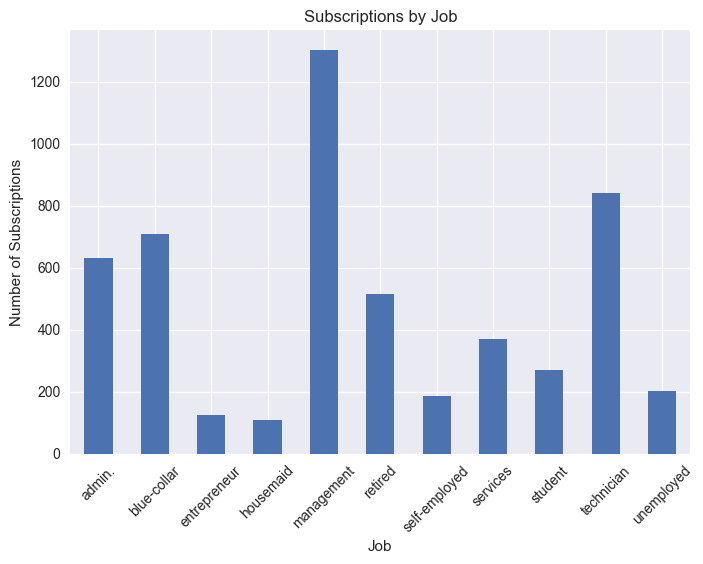

In [22]:
job_subs = df.groupby('job')['y'].value_counts().unstack()

job_subs['yes'].plot(kind='bar')

plt.title('Subscriptions by Job')
plt.xlabel('Job')
plt.ylabel('Number of Subscriptions')
plt.xticks(rotation=45)

plt.show()

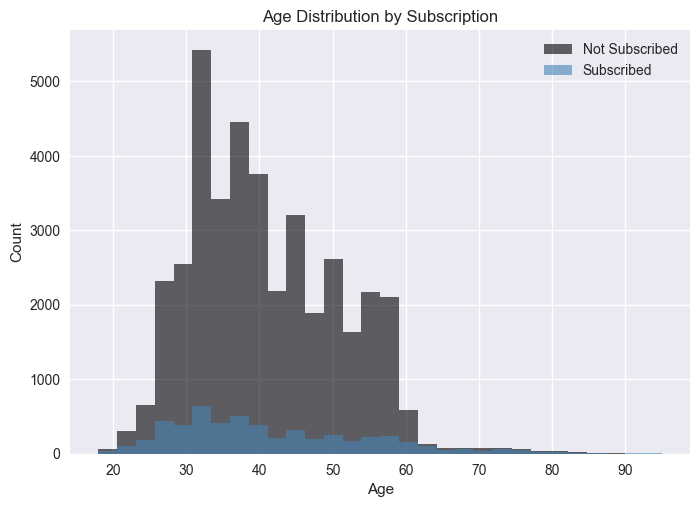

In [23]:
plt.hist(df[df['y']=='no']['age'], bins=30, alpha=0.6, label='Not Subscribed', color='black')
plt.hist(df[df['y']=='yes']['age'], bins=30, alpha=0.6, label='Subscribed', color='steelblue')

plt.title('Age Distribution by Subscription')
plt.xlabel('Age')
plt.ylabel('Count')

plt.legend()
plt.show()

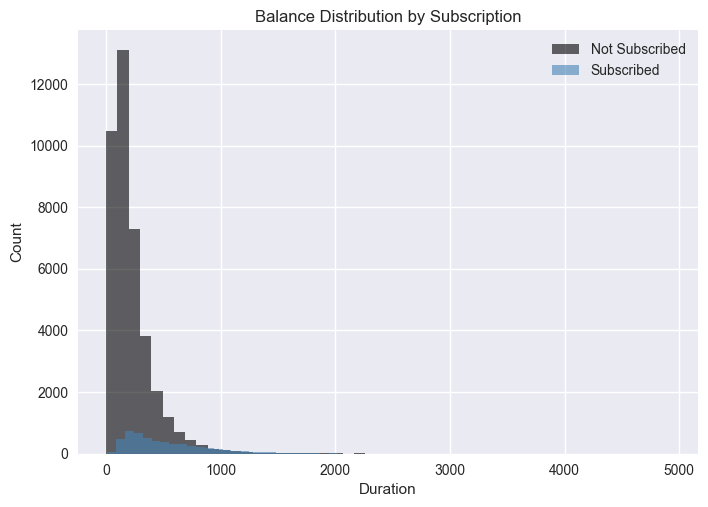

In [24]:
plt.hist(df[df['y']=='no']['duration'], bins=50, alpha=0.6, label='Not Subscribed', color='black')
plt.hist(df[df['y']=='yes']['duration'], bins=50, alpha=0.6, label='Subscribed', color='steelblue')

plt.title('Balance Distribution by Subscription')
plt.xlabel('Duration')
plt.ylabel('Count')

plt.legend()
plt.show()

In [32]:
print(df.head())

   customer_id  age           job  marital  education default  balance  \
0            1   58    management  married   tertiary      no     2143   
1            2   44    technician   single  secondary      no       29   
2            3   33  entrepreneur  married  secondary      no        2   
3            4   47   blue-collar  married        NaN      no     1506   
4            5   33           NaN   single        NaN      no        1   

  housing loan contact  day_of_week month  duration  campaign  pdays  \
0     yes   no     NaN            5   may       261         1     -1   
1     yes   no     NaN            5   may       151         1     -1   
2     yes  yes     NaN            5   may        76         1     -1   
3     yes   no     NaN            5   may        92         1     -1   
4      no   no     NaN            5   may       198         1     -1   

   previous poutcome   y  
0         0      NaN  no  
1         0      NaN  no  
2         0      NaN  no  
3         0   

In [57]:
%%sql
SELECT DISTINCT "default", COUNT(*)
FROM customers

 * sqlite:///bank_marketing.db
Done.


,default,COUNT(*)
0,no,45211
